# 05. Acquisition 분석

이 노트북은 따릉이 프로젝트의 Acquisition 단계만 다룹니다.

## 분석 질문

1. 어떤 성별·연령대에서 신규가입이 많이 발생하는가?
2. 어느 시점에 신규가입이 늘거나 줄었는가?
3. 특정 세그먼트가 성장을 주도하는가?

## 추가 비교

`age_band = 기타`는 나이가 입력되지 않은 경우이므로, 아래 두 기준을 비교합니다.

- 기타 포함
- 기타 제외


In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 경로 설정 및 DB 연결

In [2]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "seoul_bike.db"
SQL_DIR = PROJECT_ROOT / "sql"
REPORT_DIR = PROJECT_ROOT / "reports"
IMAGE_DIR = PROJECT_ROOT / "images/acquisition"

if not DB_PATH.exists() and Path("/mnt/data/seoul_bike.db").exists():
    PROJECT_ROOT = Path("/mnt/data")
    DB_PATH = PROJECT_ROOT / "seoul_bike.db"
    SQL_DIR = PROJECT_ROOT
    REPORT_DIR = PROJECT_ROOT
    IMAGE_DIR = PROJECT_ROOT / "images/acquisition"

SQL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DB_PATH:", DB_PATH)

PROJECT_ROOT: d:\seoul-bike-aarrr-analysis
DB_PATH: d:\seoul-bike-aarrr-analysis\data\seoul_bike.db


In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
if "mart_signup_segment_month" not in set(tables["name"]):
    raise ValueError("mart_signup_segment_month 테이블이 없습니다. 04_make_mart_tables 실행 후 다시 실행하세요.")
print("mart_signup_segment_month 확인 완료")

mart_signup_segment_month 확인 완료


## 2. 분석 SQL 저장

In [35]:
ACQUISITION_SQL = r"""-- 06_acquisition_analysis.sql
-- Acquisition 분석: age_band='기타' 포함/제외 비교
-- 사용 테이블: mart_signup_segment_month

-- 0. age_band='기타' 전체 비중
SELECT
    SUM(signup_cnt) AS total_signup_cnt,
    SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) AS other_signup_cnt,
    SUM(CASE WHEN age_band <> '기타' THEN signup_cnt ELSE 0 END) AS valid_age_signup_cnt,
    ROUND(1.0 * SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) / SUM(signup_cnt), 4) AS other_age_share
FROM mart_signup_segment_month;

-- 1. 월별 age_band='기타' 영향
SELECT
    month_ym,
    month_date,
    SUM(signup_cnt) AS signup_cnt_include_other,
    SUM(CASE WHEN age_band <> '기타' THEN signup_cnt ELSE 0 END) AS signup_cnt_exclude_other,
    SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) AS other_signup_cnt,
    ROUND(CASE WHEN SUM(signup_cnt) > 0 THEN 1.0 * SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) / SUM(signup_cnt) ELSE NULL END, 4) AS other_age_share
FROM mart_signup_segment_month
GROUP BY month_ym, month_date
ORDER BY month_ym;

-- Q1. 성별·연령대별 신규가입 규모: 기타 포함/제외 비교
WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
segment AS (
    SELECT scope, gender, age_band, SUM(signup_cnt) AS signup_cnt, ROUND(AVG(signup_cnt), 2) AS avg_monthly_signup_cnt, COUNT(DISTINCT month_ym) AS active_month_count
    FROM scoped
    GROUP BY scope, gender, age_band
),
scope_total AS (
    SELECT scope, SUM(signup_cnt) AS total_signup_cnt
    FROM segment
    GROUP BY scope
),
ranked AS (
    SELECT s.scope, RANK() OVER (PARTITION BY s.scope ORDER BY s.signup_cnt DESC) AS signup_rank, s.gender, s.age_band, s.signup_cnt, ROUND(1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS signup_share, s.avg_monthly_signup_cnt, s.active_month_count
    FROM segment s JOIN scope_total t ON s.scope = t.scope
)
SELECT * FROM ranked ORDER BY scope, signup_rank;

-- Q2-A. 월별 신규가입 추이 + 전월 대비 변화
WITH duration AS(
    SELECT *
    FROM mart_signup_segment_month
    UNION ALL
    SELECT month_ym, month_date, gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM stg_signup_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT month_ym, month_date, SUM(signup_cnt) AS signup_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
),
with_mom AS (
    SELECT *, LAG(signup_cnt) OVER (ORDER BY month_ym) AS prev_month_signup_cnt
    FROM monthly
)
SELECT month_ym, month_date, signup_cnt, signup_cnt - prev_month_signup_cnt AS mom_signup_diff,
       ROUND(CASE WHEN prev_month_signup_cnt > 0 THEN 1.0 * (signup_cnt - prev_month_signup_cnt) / prev_month_signup_cnt ELSE NULL END, 4) AS mom_signup_growth_rate
FROM with_mom
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym;

-- Q2-B. 전년동월 대비 변화
WITH monthly AS (
    SELECT month_ym, month_date, SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
)
SELECT cur.month_ym, cur.month_date, cur.signup_cnt AS signup_cnt, prev.signup_cnt AS prev_year_same_month_signup_cnt,
       cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff,
       ROUND(CASE WHEN prev.signup_cnt > 0 THEN 1.0 * (cur.signup_cnt - prev.signup_cnt) / prev.signup_cnt ELSE NULL END, 4) AS yoy_signup_growth_rate
FROM monthly cur
JOIN monthly prev ON cur.month_ym = prev.month_ym + 100
ORDER BY cur.month_ym;

-- Q2-C. 계절성 확인
WITH monthly AS (
    SELECT month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym
)
SELECT month_no,
       SUM(CASE WHEN year_no = 2024 THEN signup_cnt ELSE 0 END) AS signup_cnt_2024,
       SUM(CASE WHEN year_no = 2025 THEN signup_cnt ELSE 0 END) AS signup_cnt_2025,
       ROUND(AVG(signup_cnt), 2) AS avg_signup_cnt,
       COUNT(*) AS year_count
FROM monthly
GROUP BY month_no
ORDER BY month_no;

-- Q3. 성별·연령대별 전년동월 대비 성장 기여
WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_segment AS (
    SELECT scope, month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM scoped
    GROUP BY scope, month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.scope, cur.gender, cur.age_band, cur.month_no, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.scope = prev.scope AND cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
segment_growth AS (
    SELECT scope, gender, age_band, SUM(signup_cnt_2024) AS signup_cnt_2024, SUM(signup_cnt_2025) AS signup_cnt_2025, SUM(yoy_signup_diff) AS yoy_signup_diff
    FROM yoy_segment
    GROUP BY scope, gender, age_band
),
total_growth AS (
    SELECT scope, SUM(yoy_signup_diff) AS total_yoy_signup_diff
    FROM segment_growth
    GROUP BY scope
)
SELECT sg.scope, RANK() OVER (PARTITION BY sg.scope ORDER BY sg.yoy_signup_diff DESC) AS growth_rank, sg.gender, sg.age_band, sg.signup_cnt_2024, sg.signup_cnt_2025, sg.yoy_signup_diff,
       ROUND(CASE WHEN sg.signup_cnt_2024 > 0 THEN 1.0 * sg.yoy_signup_diff / sg.signup_cnt_2024 ELSE NULL END, 4) AS yoy_signup_growth_rate,
       ROUND(CASE WHEN tg.total_yoy_signup_diff != 0 THEN 1.0 * sg.yoy_signup_diff / tg.total_yoy_signup_diff ELSE NULL END, 4) AS growth_contribution_share
FROM segment_growth sg
JOIN total_growth tg ON sg.scope = tg.scope
ORDER BY sg.scope, growth_rank;

WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_segment AS (
    SELECT scope, month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM scoped
    GROUP BY scope, month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.scope, cur.gender, cur.age_band, cur.month_no, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.scope = prev.scope AND cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
segment_growth AS (
    SELECT scope, gender, age_band, SUM(signup_cnt_2024) AS signup_cnt_2024, SUM(signup_cnt_2025) AS signup_cnt_2025, SUM(yoy_signup_diff) AS yoy_signup_diff
    FROM yoy_segment
    GROUP BY scope, gender, age_band
),
total_growth AS (
    SELECT scope, SUM(yoy_signup_diff) AS total_yoy_signup_diff
    FROM segment_growth
    GROUP BY scope
),
with_metrics AS(
	SELECT sg.scope, sg.gender, sg.age_band, sg.signup_cnt_2024, sg.signup_cnt_2025, sg.yoy_signup_diff,
	       ROUND(CASE WHEN sg.signup_cnt_2024 > 0 THEN 1.0 * sg.yoy_signup_diff / sg.signup_cnt_2024 ELSE NULL END, 4) AS yoy_signup_growth_rate,
           ROUND(CASE WHEN tg.total_yoy_signup_diff != 0 THEN 1.0 * sg.yoy_signup_diff / tg.total_yoy_signup_diff ELSE NULL END, 4) AS growth_contribution_share
	FROM segment_growth sg
	JOIN total_growth tg ON sg.scope = tg.scope
)
SELECT
    scope,
    RANK() OVER (PARTITION BY scope ORDER BY yoy_signup_growth_rate DESC) AS rate_rank,
    gender, age_band, signup_cnt_2024, signup_cnt_2025,
    yoy_signup_diff,
    yoy_signup_growth_rate,
    growth_contribution_share
FROM with_metrics
ORDER BY scope, rate_rank;

--월별 성장 주도 세그먼트 TOP3
WITH monthly_segment AS (
    SELECT month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.month_ym, cur.gender, cur.age_band, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
ranked AS (
    SELECT *, RANK() OVER (PARTITION BY month_ym ORDER BY yoy_signup_diff DESC) AS growth_rank_in_month
    FROM yoy_segment
)
SELECT month_ym, growth_rank_in_month, gender, age_band, signup_cnt_2024, signup_cnt_2025, yoy_signup_diff
FROM ranked
WHERE growth_rank_in_month <= 3
ORDER BY month_ym, growth_rank_in_month;

WITH monthly_segment AS (
    SELECT
        month_ym,
        CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
        CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
        gender,
        age_band,
        SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        gender,
        age_band
),
yoy_segment AS (
    SELECT
        cur.month_ym,
        cur.gender,
        cur.age_band,
        prev.signup_cnt AS signup_cnt_2024,
        cur.signup_cnt AS signup_cnt_2025,
        cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff,
        CASE
            WHEN prev.signup_cnt > 0
            THEN 1.0 * (cur.signup_cnt - prev.signup_cnt) / prev.signup_cnt
            ELSE NULL
        END AS yoy_signup_growth_rate
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.gender = prev.gender
     AND cur.age_band = prev.age_band
     AND cur.month_no = prev.month_no
     AND cur.year_no = 2025
     AND prev.year_no = 2024
),
ranked AS (
    SELECT
        *,
        RANK() OVER (
            PARTITION BY month_ym
            ORDER BY yoy_signup_growth_rate DESC
        ) AS rate_rank_in_month
    FROM yoy_segment
)
SELECT
    month_ym,
    rate_rank_in_month,
    gender,
    age_band,
    signup_cnt_2024,
    signup_cnt_2025,
    yoy_signup_diff,
    ROUND(yoy_signup_growth_rate, 4) AS yoy_signup_growth_rate
FROM ranked
WHERE rate_rank_in_month <= 3
ORDER BY
    month_ym,
    rate_rank_in_month;
"""
(SQL_DIR / "06_acquisition_analysis.sql").write_text(ACQUISITION_SQL, encoding="utf-8")
print("SQL 저장:", SQL_DIR / "06_acquisition_analysis.sql")

SQL 저장: d:\seoul-bike-aarrr-analysis\sql\06_acquisition_analysis.sql


## 3. `age_band = 기타` 비중 확인

먼저 기타 연령대가 전체 신규가입에서 어느 정도 비중인지 확인합니다. 기타 비중이 크면 세그먼트 해석에서 왜곡 가능성이 있으므로 포함/제외 결과를 함께 봐야 합니다.

In [5]:
other_share_df = pd.read_sql_query('''
SELECT
    SUM(signup_cnt) AS total_signup_cnt,
    SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) AS other_signup_cnt,
    SUM(CASE WHEN age_band <> '기타' THEN signup_cnt ELSE 0 END) AS valid_age_signup_cnt,
    ROUND(1.0 * SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) / SUM(signup_cnt), 4) AS other_age_share
FROM mart_signup_segment_month
''', conn)
other_share_df

,total_signup_cnt,other_signup_cnt,valid_age_signup_cnt,other_age_share
0,899189,22890,876299,0.0255


In [6]:
monthly_other_df = pd.read_sql_query('''
SELECT
    month_ym,
    month_date,
    SUM(signup_cnt) AS signup_cnt_include_other,
    SUM(CASE WHEN age_band <> '기타' THEN signup_cnt ELSE 0 END) AS signup_cnt_exclude_other,
    SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) AS other_signup_cnt,
    ROUND(CASE WHEN SUM(signup_cnt) > 0 THEN 1.0 * SUM(CASE WHEN age_band = '기타' THEN signup_cnt ELSE 0 END) / SUM(signup_cnt) ELSE NULL END, 4) AS other_age_share
FROM mart_signup_segment_month
GROUP BY month_ym, month_date
ORDER BY month_ym
''', conn)
monthly_other_df.head(24)

,month_ym,month_date,signup_cnt_include_other,signup_cnt_exclude_other,other_signup_cnt,other_age_share
0,202401,2024-01-01,14081,14048,33,0.0023
1,202402,2024-02-01,41162,41036,126,0.0031
2,202403,2024-03-01,52195,52098,97,0.0019
3,202404,2024-04-01,82167,82031,136,0.0017
4,202405,2024-05-01,66090,65972,118,0.0018
5,202406,2024-06-01,54367,54281,86,0.0016
6,202407,2024-07-01,31388,31322,66,0.0021
7,202408,2024-08-01,34215,34146,69,0.0020
8,202409,2024-09-01,50381,50294,87,0.0017
9,202410,2024-10-01,53856,53783,73,0.0014


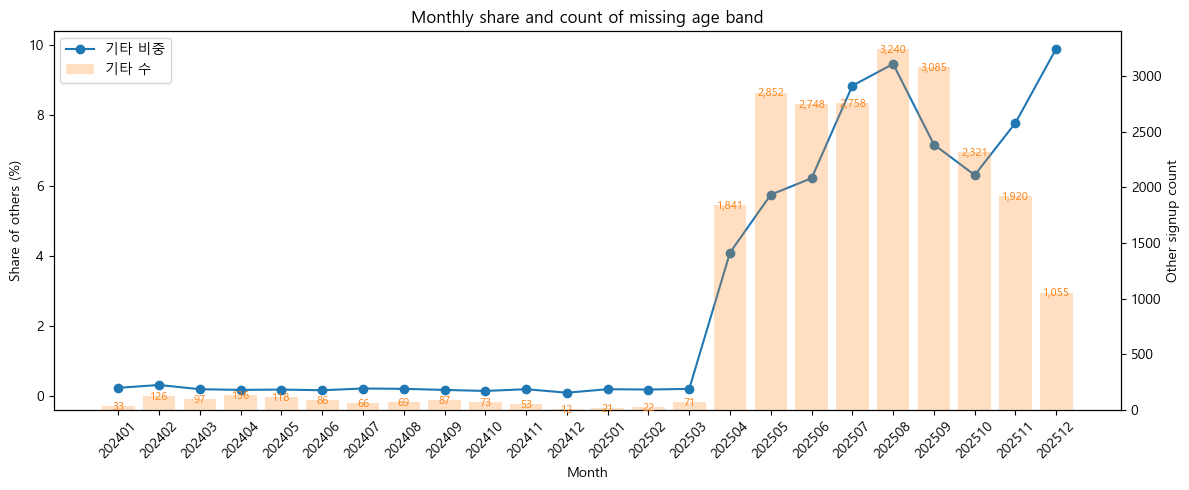

In [7]:
months = monthly_other_df["month_ym"].astype(str)
other_share_pct = monthly_other_df["other_age_share"] * 100
other_counts = monthly_other_df["other_signup_cnt"]

fig, ax_share = plt.subplots(figsize=(12, 5))
ax_count = ax_share.twinx()

bars = ax_count.bar(months, other_counts, color="tab:orange", alpha=0.25, label="기타 수")
line = ax_share.plot(months, other_share_pct, color="tab:blue", marker="o", label="기타 비중")

ax_share.set_title("Monthly share and count of missing age band")
ax_share.set_xlabel("Month")
ax_share.set_ylabel("Share of others (%)")
ax_count.set_ylabel("Other signup count")
ax_share.tick_params(axis="x", rotation=45)

ax_count.bar_label(
    bars,
    labels=[f"{int(count):,}" for count in other_counts],
    padding=-5,
    rotation=0,
    fontsize=8,
    color="tab:orange",
)

handles = [line[0], bars]
labels = [handle.get_label() for handle in handles]
ax_share.legend(handles, labels, loc="upper left")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_00_other_age_share.png", dpi=150)
plt.show()

## 4. 질문 1: 어떤 성별·연령대에서 신규가입이 많이 발생하는가?

세그먼트 해석은 `기타 제외` 결과를 중심으로 봅니다.

In [8]:
segment_signup_df = pd.read_sql_query('''
WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
segment AS (
    SELECT scope, gender, age_band, SUM(signup_cnt) AS signup_cnt, ROUND(AVG(signup_cnt), 2) AS avg_monthly_signup_cnt, COUNT(DISTINCT month_ym) AS active_month_count
    FROM scoped
    GROUP BY scope, gender, age_band
),
scope_total AS (
    SELECT scope, SUM(signup_cnt) AS total_signup_cnt
    FROM segment
    GROUP BY scope
),
ranked AS (
    SELECT s.scope, RANK() OVER (PARTITION BY s.scope ORDER BY s.signup_cnt DESC) AS signup_rank, s.gender, s.age_band, s.signup_cnt, ROUND(1.0 * s.signup_cnt / t.total_signup_cnt, 4) AS signup_share, s.avg_monthly_signup_cnt, s.active_month_count
    FROM segment s JOIN scope_total t ON s.scope = t.scope
)
SELECT * FROM ranked ORDER BY scope, signup_rank
''', conn)
segment_signup_df.head(35)

,scope,signup_rank,gender,age_band,signup_cnt,signup_share,avg_monthly_signup_cnt,active_month_count
0,exclude_other,1,M,20대,141409,0.1614,5892.04,24
1,exclude_other,2,F,20대,141196,0.1611,5883.17,24
2,exclude_other,3,M,30대,97687,0.1115,4070.29,24
3,exclude_other,4,M,~10대,93721,0.1070,3905.04,24
4,exclude_other,5,M,40대,80755,0.0922,3364.79,24
5,exclude_other,6,F,30대,76817,0.0877,3200.71,24
6,exclude_other,7,F,~10대,62760,0.0716,2615.00,24
7,exclude_other,8,F,40대,61250,0.0699,2552.08,24
8,exclude_other,9,M,50대,51258,0.0585,2135.75,24
9,exclude_other,10,F,50대,33887,0.0387,1411.96,24


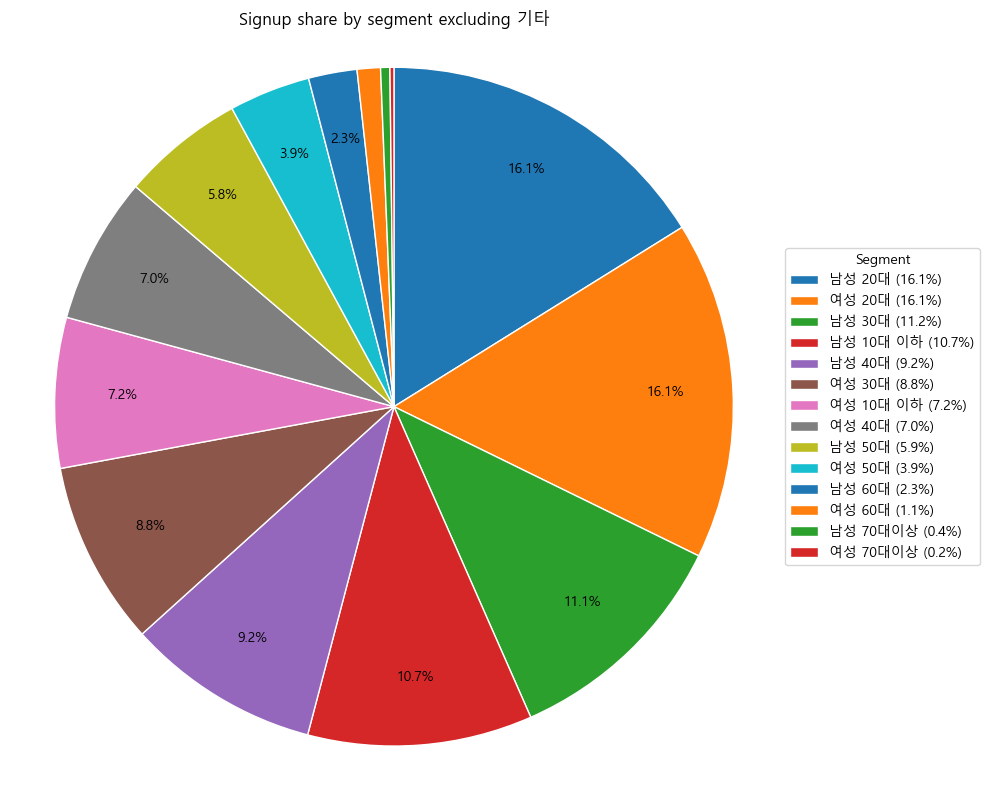

In [9]:
top_exclude_segment_df = segment_signup_df[segment_signup_df["scope"] == "exclude_other"].copy()

def format_segment_label(gender, age_band):
    gender_label = {"M": "남성", "F": "여성"}.get(str(gender), str(gender))
    age_text = str(age_band)
    if age_text == "~10대":
        age_label = "10대 이하"
    else:
        age_label = age_text
    return f"{gender_label} {age_label}"

top_exclude_segment_df["segment"] = top_exclude_segment_df.apply(
    lambda row: format_segment_label(row["gender"], row["age_band"]), axis=1
)

pie_share_df = top_exclude_segment_df[["segment", "signup_share"]].copy()
pie_share_df["legend_label"] = pie_share_df.apply(
    lambda row: f"{row['segment']} ({row['signup_share']:.1%})", axis=1
)

def make_pie_autopct(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

fig, ax = plt.subplots(figsize=(10, 8))
wedges, _, _ = ax.pie(
    pie_share_df["signup_share"],
    labels=None,
    autopct=make_pie_autopct,
    startangle=90,
    counterclock=False,
    pctdistance=0.8,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
ax.set_title("Signup share by segment excluding 기타")
ax.axis("equal")
ax.legend(wedges, pie_share_df["legend_label"], title="Segment", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_01_top_signup_segments_exclude_other.png", dpi=150)
plt.show()

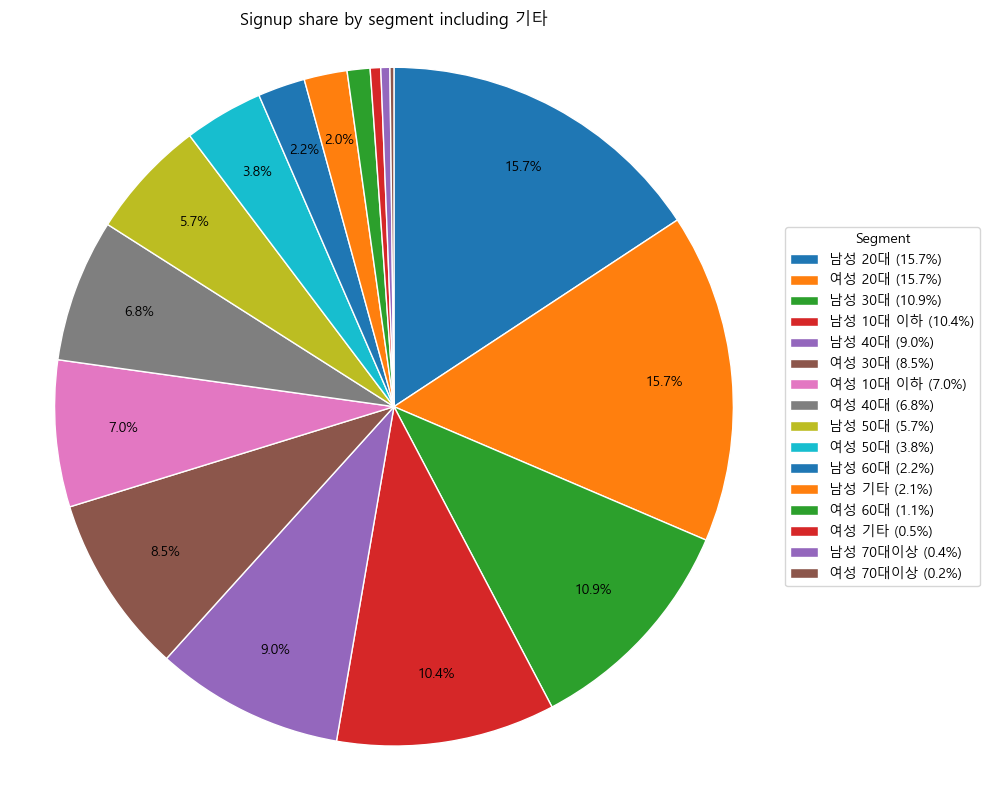

In [10]:
top_include_segment_df = segment_signup_df[segment_signup_df["scope"] == "include_other"].copy()
top_include_segment_df["segment"] = top_include_segment_df.apply(
    lambda row: format_segment_label(row["gender"], row["age_band"]), axis=1
)

pie_share_include_df = top_include_segment_df[["segment", "signup_share"]].copy()
pie_share_include_df["legend_label"] = pie_share_include_df.apply(
    lambda row: f"{row['segment']} ({row['signup_share']:.1%})", axis=1
)

fig, ax = plt.subplots(figsize=(10, 8))
wedges, _, _ = ax.pie(
    pie_share_include_df["signup_share"],
    labels=None,
    autopct=make_pie_autopct,
    startangle=90,
    counterclock=False,
    pctdistance=0.8,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
ax.set_title("Signup share by segment including 기타")
ax.axis("equal")
ax.legend(wedges, pie_share_include_df["legend_label"], title="Segment", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_01_top_signup_segments_include_other.png", dpi=150)
plt.show()

## 5. 질문 2: 어느 시점에 신규가입이 늘거나 줄었는가?

월별 신규가입 추이는 `기타 포함`과 `기타 제외`를 함께 봅니다.

In [11]:
monthly_trend_df = pd.read_sql_query('''
WITH duration AS(
    SELECT *
    FROM mart_signup_segment_month
    UNION ALL
    SELECT month_ym, month_date, gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM stg_signup_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT month_ym, month_date, SUM(signup_cnt) AS signup_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
),
with_mom AS (
    SELECT *, LAG(signup_cnt) OVER (ORDER BY month_ym) AS prev_month_signup_cnt
    FROM monthly
)
SELECT month_ym, month_date, signup_cnt, signup_cnt - prev_month_signup_cnt AS mom_signup_diff,
       ROUND(CASE WHEN prev_month_signup_cnt > 0 THEN 1.0 * (signup_cnt - prev_month_signup_cnt) / prev_month_signup_cnt ELSE NULL END, 4) AS mom_signup_growth_rate
FROM with_mom
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym
''', conn)
monthly_trend_df.head(24)

,month_ym,month_date,signup_cnt,mom_signup_diff,mom_signup_growth_rate
0,202401,2024-01-01,14081,737,0.0552
1,202402,2024-02-01,41162,27081,1.9232
2,202403,2024-03-01,52195,11033,0.2680
3,202404,2024-04-01,82167,29972,0.5742
4,202405,2024-05-01,66090,-16077,-0.1957
5,202406,2024-06-01,54367,-11723,-0.1774
6,202407,2024-07-01,31388,-22979,-0.4227
7,202408,2024-08-01,34215,2827,0.0901
8,202409,2024-09-01,50381,16166,0.4725
9,202410,2024-10-01,53856,3475,0.0690


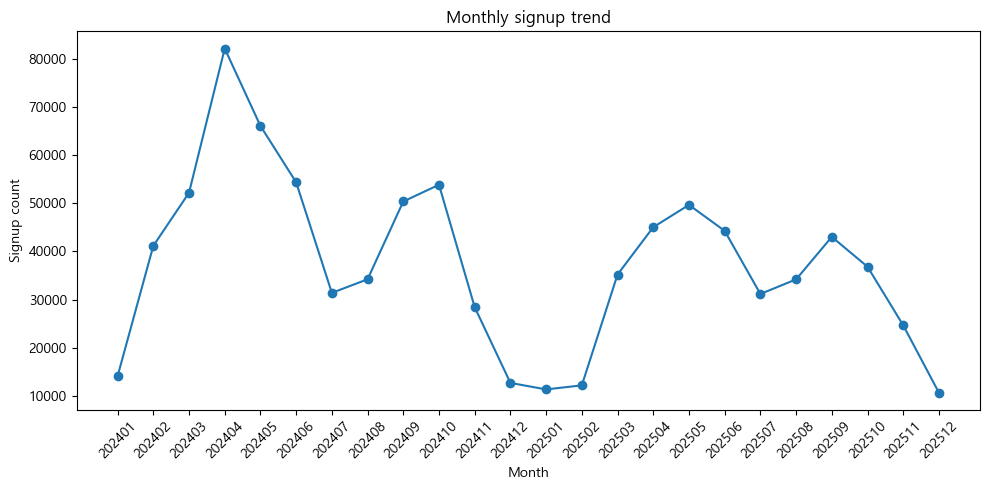

In [12]:
monthly_plot_df = monthly_trend_df.sort_values("month_ym").copy()

plt.figure(figsize=(10, 5))
plt.plot(monthly_plot_df["month_ym"].astype(str), monthly_plot_df["signup_cnt"], marker="o")
plt.title("Monthly signup trend")
plt.xlabel("Month")
plt.ylabel("Signup count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_02_monthly_signup_trend_compare.png", dpi=150)
plt.show()

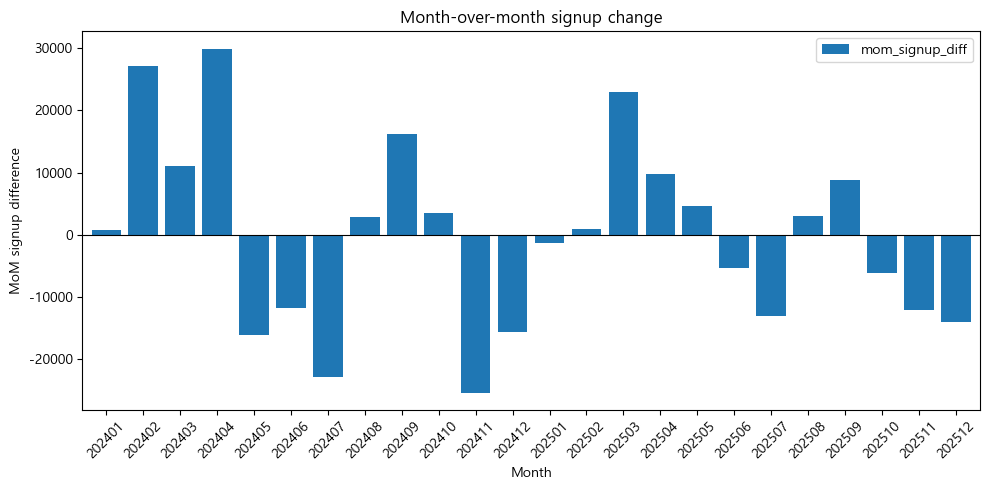

In [13]:
ax = monthly_plot_df.plot(
    x="month_ym",
    y="mom_signup_diff",
    kind="bar",
    figsize=(10, 5),
    color="#1f77b4",
    width=0.8,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-month signup change")
ax.set_xlabel("Month")
ax.set_ylabel("MoM signup difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_03_mom_signup_diff_compare_other.png", dpi=150)
plt.show()

## 6. 전년동월 대비 변화

전년동월 대비 분석은 2025년 각 월을 2024년 같은 월과 비교합니다.

In [14]:
yoy_trend_df = pd.read_sql_query('''
WITH monthly AS (
    SELECT month_ym, month_date, SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, month_date
)
SELECT cur.month_ym, cur.month_date, cur.signup_cnt AS signup_cnt, prev.signup_cnt AS prev_year_same_month_signup_cnt,
       cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff,
       ROUND(CASE WHEN prev.signup_cnt > 0 THEN 1.0 * (cur.signup_cnt - prev.signup_cnt) / prev.signup_cnt ELSE NULL END, 4) AS yoy_signup_growth_rate
FROM monthly cur
JOIN monthly prev ON cur.month_ym = prev.month_ym + 100
ORDER BY cur.month_ym
''', conn)
yoy_trend_df

,month_ym,month_date,signup_cnt,prev_year_same_month_signup_cnt,yoy_signup_diff,yoy_signup_growth_rate
0,202501,2025-01-01,11326,14081,-2755,-0.1957
1,202502,2025-02-01,12171,41162,-28991,-0.7043
2,202503,2025-03-01,35201,52195,-16994,-0.3256
3,202504,2025-04-01,45040,82167,-37127,-0.4518
4,202505,2025-05-01,49676,66090,-16414,-0.2484
5,202506,2025-06-01,44279,54367,-10088,-0.1856
6,202507,2025-07-01,31162,31388,-226,-0.0072
7,202508,2025-08-01,34196,34215,-19,-0.0006
8,202509,2025-09-01,43027,50381,-7354,-0.1460
9,202510,2025-10-01,36824,53856,-17032,-0.3163


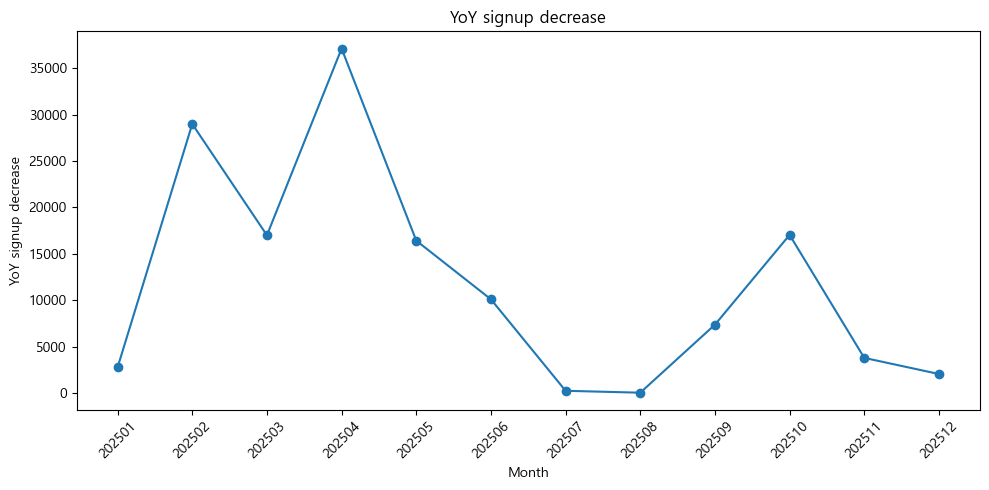

In [15]:
yoy_plot = yoy_trend_df.sort_values("month_ym").copy()

plt.figure(figsize=(10, 5))
plt.plot(yoy_plot["month_ym"].astype(str), -yoy_plot["yoy_signup_diff"], marker="o")
plt.title("YoY signup decrease")
plt.xlabel("Month")
plt.ylabel("YoY signup decrease")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_04_yoy_signup_diff_compare.png", dpi=150)
plt.show()

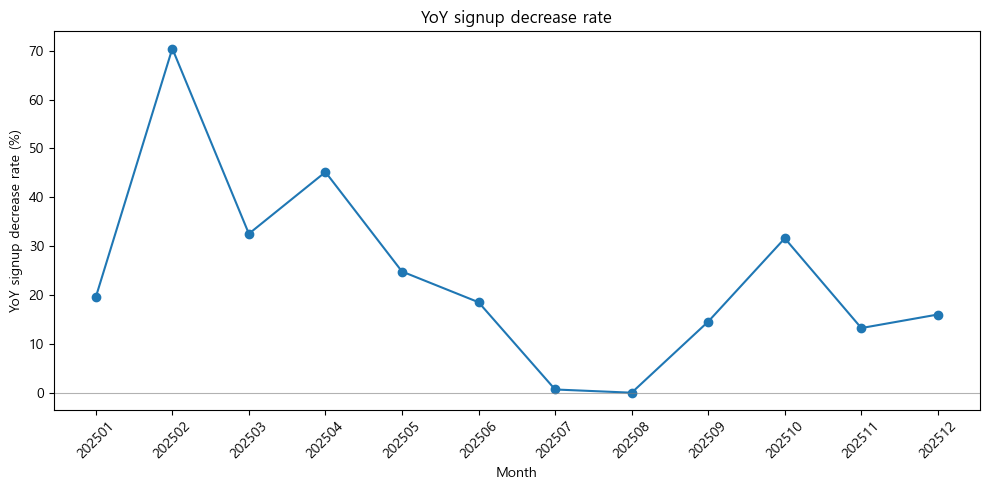

In [16]:
yoy_rate_plot = yoy_trend_df.sort_values("month_ym").copy()
yoy_rate_plot["decrease_rate_pct"] = -yoy_rate_plot["yoy_signup_growth_rate"] * 100

plt.figure(figsize=(10, 5))
plt.plot(yoy_rate_plot["month_ym"].astype(str), yoy_rate_plot["decrease_rate_pct"], marker="o")
plt.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
plt.title("YoY signup decrease rate")
plt.xlabel("Month")
plt.ylabel("YoY signup decrease rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_04_yoy_signup_decrease_rate_compare.png", dpi=150)
plt.show()

## 7. 계절성 확인

월 번호 기준으로 신규가입이 반복적으로 높은 달이 있는지 확인합니다. 데이터가 2개년뿐이므로 확정적인 계절성이 아니라 계절성 가능성으로 해석합니다.

In [17]:
seasonality_df = pd.read_sql_query('''
WITH monthly AS (
    SELECT month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym
)
SELECT month_no,
       SUM(CASE WHEN year_no = 2024 THEN signup_cnt ELSE 0 END) AS signup_cnt_2024,
       SUM(CASE WHEN year_no = 2025 THEN signup_cnt ELSE 0 END) AS signup_cnt_2025,
       ROUND(AVG(signup_cnt), 2) AS avg_signup_cnt,
       COUNT(*) AS year_count
FROM monthly
GROUP BY month_no
ORDER BY month_no
''', conn)
seasonality_df

,month_no,signup_cnt_2024,signup_cnt_2025,avg_signup_cnt,year_count
0,1,14081,11326,12703.5,2
1,2,41162,12171,26666.5,2
2,3,52195,35201,43698.0,2
3,4,82167,45040,63603.5,2
4,5,66090,49676,57883.0,2
5,6,54367,44279,49323.0,2
6,7,31388,31162,31275.0,2
7,8,34215,34196,34205.5,2
8,9,50381,43027,46704.0,2
9,10,53856,36824,45340.0,2


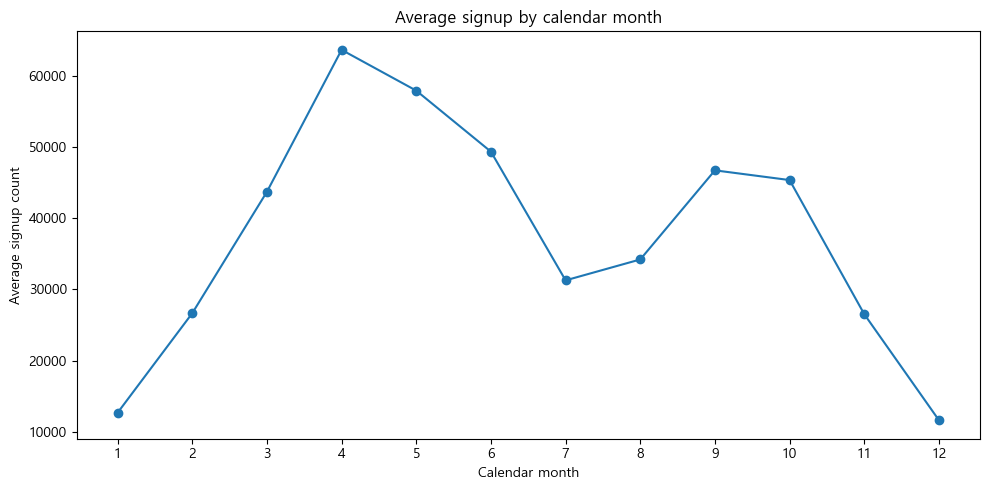

In [18]:
seasonality_plot = seasonality_df.sort_values("month_no").copy()

plt.figure(figsize=(10, 5))
plt.plot(seasonality_plot["month_no"].astype(str), seasonality_plot["avg_signup_cnt"], marker="o")
plt.title("Average signup by calendar month")
plt.xlabel("Calendar month")
plt.ylabel("Average signup count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_05_seasonality_compare.png", dpi=150)
plt.show()

## 8. 질문 3: 특정 세그먼트가 성장을 주도하는가?

2025년과 2024년의 같은 월을 비교하여 세그먼트별 전년동월 대비 증가분을 계산합니다. 성장 주도 세그먼트 해석은 `기타 제외` 결과를 중심으로 봅니다.

In [19]:
segment_growth_df = pd.read_sql_query('''
WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_segment AS (
    SELECT scope, month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM scoped
    GROUP BY scope, month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.scope, cur.gender, cur.age_band, cur.month_no, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.scope = prev.scope AND cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
segment_growth AS (
    SELECT scope, gender, age_band, SUM(signup_cnt_2024) AS signup_cnt_2024, SUM(signup_cnt_2025) AS signup_cnt_2025, SUM(yoy_signup_diff) AS yoy_signup_diff
    FROM yoy_segment
    GROUP BY scope, gender, age_band
),
total_growth AS (
    SELECT scope, SUM(yoy_signup_diff) AS total_yoy_signup_diff
    FROM segment_growth
    GROUP BY scope
)
SELECT sg.scope, RANK() OVER (PARTITION BY sg.scope ORDER BY sg.yoy_signup_diff DESC) AS growth_rank, sg.gender, sg.age_band, sg.signup_cnt_2024, sg.signup_cnt_2025, sg.yoy_signup_diff,
       ROUND(CASE WHEN sg.signup_cnt_2024 > 0 THEN 1.0 * sg.yoy_signup_diff / sg.signup_cnt_2024 ELSE NULL END, 4) AS yoy_signup_growth_rate,
       ROUND(CASE WHEN tg.total_yoy_signup_diff != 0 THEN 1.0 * sg.yoy_signup_diff / tg.total_yoy_signup_diff ELSE NULL END, 4) AS growth_contribution_share
FROM segment_growth sg
JOIN total_growth tg ON sg.scope = tg.scope
ORDER BY sg.scope, growth_rank
''', conn)
segment_growth_df.head(30)

,scope,growth_rank,gender,age_band,signup_cnt_2024,signup_cnt_2025,yoy_signup_diff,yoy_signup_growth_rate,growth_contribution_share
0,exclude_other,1,F,70대이상,1032,667,-365,-0.3537,0.0022
1,exclude_other,2,M,70대이상,2149,1706,-443,-0.2061,0.0027
2,exclude_other,3,F,60대,6184,3585,-2599,-0.4203,0.0159
3,exclude_other,4,M,60대,12507,7724,-4783,-0.3824,0.0292
4,exclude_other,5,F,~10대,35361,27399,-7962,-0.2252,0.0486
5,exclude_other,6,F,50대,21797,12090,-9707,-0.4453,0.0593
6,exclude_other,7,M,~10대,52007,41714,-10293,-0.1979,0.0628
7,exclude_other,8,F,40대,36787,24463,-12324,-0.3350,0.0752
8,exclude_other,9,M,50대,32222,19036,-13186,-0.4092,0.0805
9,exclude_other,10,F,30대,46007,30810,-15197,-0.3303,0.0928


In [ ]:
segment_growth_rate_df = pd.read_sql_query('''
WITH scoped AS (
    SELECT 'include_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    UNION ALL
    SELECT 'exclude_other' AS scope, month_ym, gender, age_band, signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_segment AS (
    SELECT scope, month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM scoped
    GROUP BY scope, month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.scope, cur.gender, cur.age_band, cur.month_no, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.scope = prev.scope AND cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
segment_growth AS (
    SELECT scope, gender, age_band, SUM(signup_cnt_2024) AS signup_cnt_2024, SUM(signup_cnt_2025) AS signup_cnt_2025, SUM(yoy_signup_diff) AS yoy_signup_diff
    FROM yoy_segment
    GROUP BY scope, gender, age_band
),
total_growth AS (
    SELECT scope, SUM(yoy_signup_diff) AS total_yoy_signup_diff
    FROM segment_growth
    GROUP BY scope
),
with_metrics AS(
	SELECT sg.scope, sg.gender, sg.age_band, sg.signup_cnt_2024, sg.signup_cnt_2025, sg.yoy_signup_diff,
	       ROUND(CASE WHEN sg.signup_cnt_2024 > 0 THEN 1.0 * sg.yoy_signup_diff / sg.signup_cnt_2024 ELSE NULL END, 4) AS yoy_signup_growth_rate,
           ROUND(CASE WHEN tg.total_yoy_signup_diff != 0 THEN 1.0 * sg.yoy_signup_diff / tg.total_yoy_signup_diff ELSE NULL END, 4) AS growth_contribution_share
	FROM segment_growth sg
	JOIN total_growth tg ON sg.scope = tg.scope
)
SELECT
    scope,
    RANK() OVER (PARTITION BY scope ORDER BY yoy_signup_growth_rate DESC) AS rate_rank,
    gender, age_band, signup_cnt_2024, signup_cnt_2025,
    yoy_signup_diff,
    yoy_signup_growth_rate,
    growth_contribution_share
FROM with_metrics
ORDER BY scope, rate_rank
''', conn)
segment_growth_rate_df.head(30)

,scope,rate_rank,gender,age_band,signup_cnt_2024,signup_cnt_2025,yoy_signup_diff,yoy_signup_growth_rate,growth_contribution_share
0,exclude_other,1,M,~10대,52007,41714,-10293,-0.1979,0.0628
1,exclude_other,2,M,70대이상,2149,1706,-443,-0.2061,0.0027
2,exclude_other,3,F,~10대,35361,27399,-7962,-0.2252,0.0486
3,exclude_other,4,M,20대,82774,58635,-24139,-0.2916,0.1474
4,exclude_other,5,F,20대,84110,57086,-27024,-0.3213,0.1650
5,exclude_other,6,M,30대,58434,39253,-19181,-0.3283,0.1171
6,exclude_other,7,F,30대,46007,30810,-15197,-0.3303,0.0928
7,exclude_other,8,F,40대,36787,24463,-12324,-0.3350,0.0752
8,exclude_other,9,M,40대,48669,32086,-16583,-0.3407,0.1012
9,exclude_other,10,F,70대이상,1032,667,-365,-0.3537,0.0022


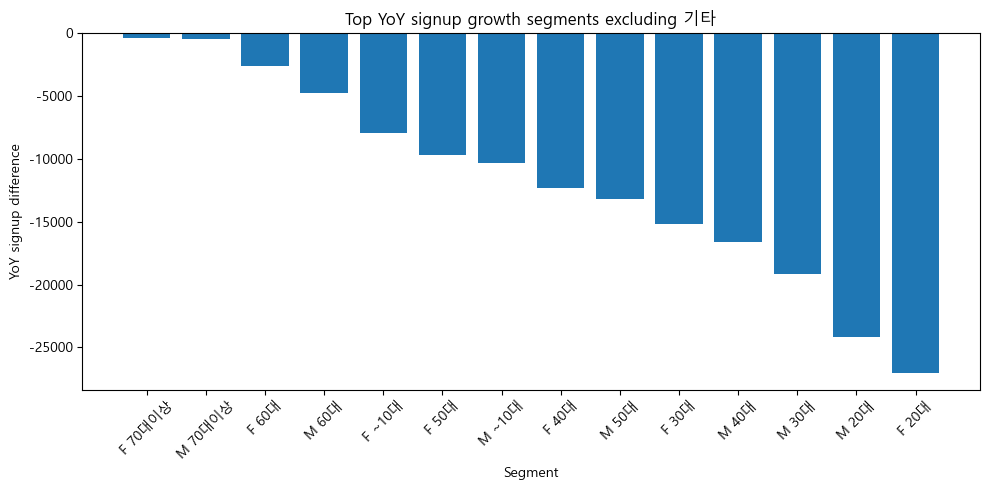

In [29]:
growth_exclude_df = segment_growth_df[segment_growth_df["scope"] == "exclude_other"].copy()
growth_exclude_df["segment"] = growth_exclude_df["gender"].astype(str) + " " + growth_exclude_df["age_band"].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(growth_exclude_df["segment"], growth_exclude_df["yoy_signup_diff"])
plt.title("Top YoY signup growth segments excluding 기타")
plt.xlabel("Segment")
plt.ylabel("YoY signup difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_06_growth_driver_segments_exclude_other.png", dpi=150)
plt.show()

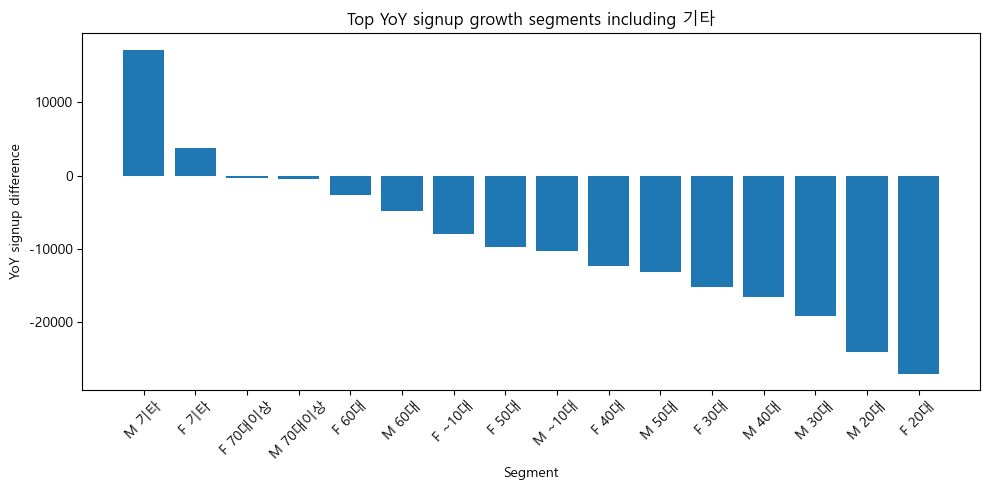

In [22]:
growth_include_df = segment_growth_df[segment_growth_df["scope"] == "include_other"].copy()
growth_include_df["segment"] = growth_include_df["gender"].astype(str) + " " + growth_include_df["age_band"].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(growth_include_df["segment"], growth_include_df["yoy_signup_diff"])
plt.title("Top YoY signup growth segments including 기타")
plt.xlabel("Segment")
plt.ylabel("YoY signup difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_06_growth_driver_segments_include_other.png", dpi=150)
plt.show()

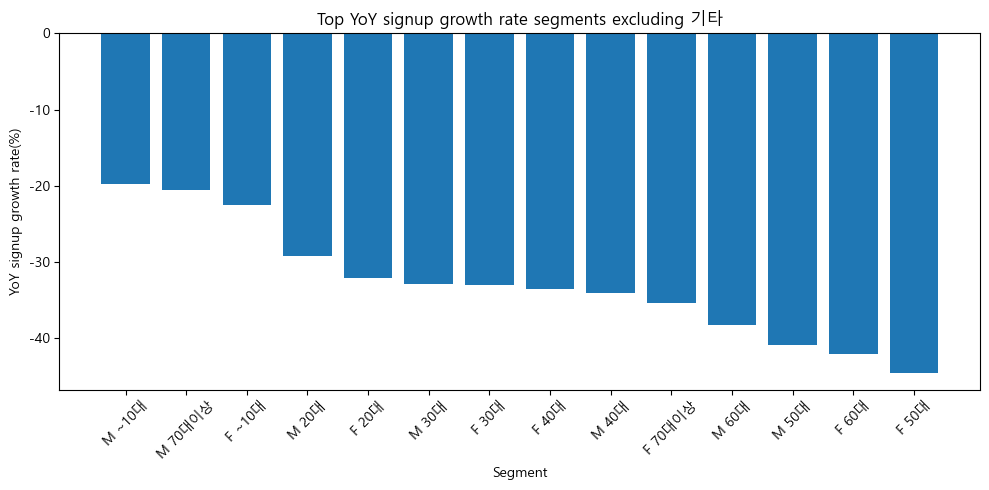

In [30]:
growth_rate_exclude_df = segment_growth_rate_df[segment_growth_df["scope"] == "exclude_other"].copy()
growth_rate_exclude_df["segment"] = growth_rate_exclude_df["gender"].astype(str) + " " + growth_rate_exclude_df["age_band"].astype(str)
growth_rate_exclude_df["yoy_signup_growth_rate"] = growth_rate_exclude_df["yoy_signup_growth_rate"] * 100

plt.figure(figsize=(10, 5))
plt.bar(growth_rate_exclude_df["segment"], growth_rate_exclude_df["yoy_signup_growth_rate"])
plt.title("Top YoY signup growth rate segments excluding 기타")
plt.xlabel("Segment")
plt.ylabel("YoY signup growth rate(%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "acquisition_06_growth_rate_driver_segments_exclude_other.png", dpi=150)
plt.show()

## 9. 월별 성장 주도 세그먼트 TOP 3

In [23]:
monthly_growth_driver_df = pd.read_sql_query('''
WITH monthly_segment AS (
    SELECT month_ym,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
           CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
           gender, age_band, SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY month_ym, gender, age_band
),
yoy_segment AS (
    SELECT cur.month_ym, cur.gender, cur.age_band, cur.signup_cnt AS signup_cnt_2025, prev.signup_cnt AS signup_cnt_2024, cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.gender = prev.gender AND cur.age_band = prev.age_band AND cur.month_no = prev.month_no
     AND cur.year_no = 2025 AND prev.year_no = 2024
),
ranked AS (
    SELECT *, RANK() OVER (PARTITION BY month_ym ORDER BY yoy_signup_diff DESC) AS growth_rank_in_month
    FROM yoy_segment
)
SELECT month_ym, growth_rank_in_month, gender, age_band, signup_cnt_2024, signup_cnt_2025, yoy_signup_diff
FROM ranked
WHERE growth_rank_in_month <= 3
ORDER BY month_ym, growth_rank_in_month
''', conn)
monthly_growth_driver_df

,month_ym,growth_rank_in_month,gender,age_band,signup_cnt_2024,signup_cnt_2025,yoy_signup_diff
0,202501,1,M,~10대,1377,1932,555
1,202501,2,F,~10대,909,1151,242
2,202501,3,F,70대이상,41,20,-21
3,202502,1,F,70대이상,110,22,-88
4,202502,2,M,70대이상,237,51,-186
5,202502,3,F,60대,882,112,-770
6,202503,1,F,70대이상,99,77,-22
7,202503,2,M,70대이상,217,168,-49
8,202503,3,F,~10대,2995,2668,-327
9,202504,1,F,70대이상,148,86,-62


In [24]:
monthly_growth_rate_driver_df = pd.read_sql_query('''
WITH monthly_segment AS (
    SELECT
        month_ym,
        CAST(SUBSTR(CAST(month_ym AS TEXT), 1, 4) AS INTEGER) AS year_no,
        CAST(SUBSTR(CAST(month_ym AS TEXT), 5, 2) AS INTEGER) AS month_no,
        gender,
        age_band,
        SUM(signup_cnt) AS signup_cnt
    FROM mart_signup_segment_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        gender,
        age_band
),
yoy_segment AS (
    SELECT
        cur.month_ym,
        cur.gender,
        cur.age_band,
        prev.signup_cnt AS signup_cnt_2024,
        cur.signup_cnt AS signup_cnt_2025,
        cur.signup_cnt - prev.signup_cnt AS yoy_signup_diff,
        CASE
            WHEN prev.signup_cnt > 0
            THEN 1.0 * (cur.signup_cnt - prev.signup_cnt) / prev.signup_cnt
            ELSE NULL
        END AS yoy_signup_growth_rate
    FROM monthly_segment cur
    JOIN monthly_segment prev
      ON cur.gender = prev.gender
     AND cur.age_band = prev.age_band
     AND cur.month_no = prev.month_no
     AND cur.year_no = 2025
     AND prev.year_no = 2024
),
ranked AS (
    SELECT
        *,
        RANK() OVER (
            PARTITION BY month_ym
            ORDER BY yoy_signup_growth_rate DESC
        ) AS rate_rank_in_month
    FROM yoy_segment
)
SELECT
    month_ym,
    rate_rank_in_month,
    gender,
    age_band,
    signup_cnt_2024,
    signup_cnt_2025,
    yoy_signup_diff,
    ROUND(yoy_signup_growth_rate, 4) AS yoy_signup_growth_rate
FROM ranked
WHERE rate_rank_in_month <= 3
ORDER BY
    month_ym,
    rate_rank_in_month;
''', conn)
monthly_growth_rate_driver_df

,month_ym,rate_rank_in_month,gender,age_band,signup_cnt_2024,signup_cnt_2025,yoy_signup_diff,yoy_signup_growth_rate
0,202501,1,M,~10대,1377,1932,555,0.4031
1,202501,2,F,~10대,909,1151,242,0.2662
2,202501,3,F,40대,807,660,-147,-0.1822
3,202502,1,M,~10대,3331,2194,-1137,-0.3413
4,202502,2,F,~10대,2466,1414,-1052,-0.4266
5,202502,3,M,20대,4859,1867,-2992,-0.6158
6,202503,1,M,~10대,4309,3839,-470,-0.1091
7,202503,2,F,~10대,2995,2668,-327,-0.1092
8,202503,3,F,70대이상,99,77,-22,-0.2222
9,202504,1,M,70대이상,277,215,-62,-0.2238


## 10. 분석 요약 파일 저장

In [33]:
def df_to_md(df):
    if df is None or df.empty:
        return "_결과 없음_"
    temp = df.copy().fillna("").astype(str)
    def clean(x):
        return str(x).replace("\n", "<br>").replace("|", "\\|")
    header = "| " + " | ".join(clean(c) for c in temp.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(temp.columns)) + " |"
    rows = ["| " + " | ".join(clean(v) for v in row) + " |" for row in temp.values.tolist()]
    return "\n".join([header, sep] + rows)

summary_md = f"""# Acquisition 분석 결과 요약

## 0. age_band='기타' 비중

{df_to_md(other_share_df)}

## 1. 어떤 성별·연령대에서 신규가입이 많이 발생하는가?

### 기타 제외 기준 TOP 10

{df_to_md(segment_signup_df[segment_signup_df['scope'] == 'exclude_other'].head(10))}

### 기타 포함 기준 TOP 10

{df_to_md(segment_signup_df[segment_signup_df['scope'] == 'include_other'].head(10))}

## 2. 어느 시점에 신규가입이 늘거나 줄었는가?

### 월별 추이와 전월 대비 변화

{df_to_md(monthly_trend_df.head(30))}

### 전년동월 대비 변화

{df_to_md(yoy_trend_df)}

## 3. 계절성 확인

{df_to_md(seasonality_df)}

## 4. 특정 세그먼트가 성장을 주도하는가?

### 기타 제외 기준 성장 기여 TOP 10

{df_to_md(segment_growth_df[segment_growth_df['scope'] == 'exclude_other'].head(10))}
{df_to_md(segment_growth_rate_df[segment_growth_df['scope'] == 'exclude_other'].head(10))}

### 기타 포함 기준 성장 기여 TOP 10

{df_to_md(segment_growth_df[segment_growth_df['scope'] == 'include_other'].head(10))}
{df_to_md(segment_growth_rate_df[segment_growth_df['scope'] == 'exclude_other'].head(10))}

## 5. 월별 성장 주도 세그먼트 TOP 3

{df_to_md(monthly_growth_driver_df)}
{df_to_md(monthly_growth_rate_driver_df)}

## 해석 메모

- `age_band='기타'`는 나이가 입력되지 않은 집단이므로 세그먼트 해석에서는 제외 기준을 중심으로 본다.
- `기타 포함` 결과는 전체 신규가입 규모와 비교하기 위한 보조 결과이다.
- `signup_share`가 높은 세그먼트는 전체 신규가입에서 큰 비중을 차지한다.
- `mom_signup_diff`는 전월 대비 신규가입 증감이다.
- `yoy_signup_diff`는 2025년과 2024년 같은 월의 신규가입 차이이다.
- `growth_contribution_share`는 전체 전년동월 대비 변화분 중 해당 세그먼트가 차지하는 비중이다.
- 계절성은 2024~2025 2개년 기준이므로 확정이 아니라 가능성으로 해석한다.
"""

summary_path = REPORT_DIR / "acquisition_analysis_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

print("요약 저장:", summary_path)
print("이미지 저장 폴더:", IMAGE_DIR)

요약 저장: d:\seoul-bike-aarrr-analysis\reports\acquisition_analysis_summary.md
이미지 저장 폴더: d:\seoul-bike-aarrr-analysis\images\acquisition


In [34]:
conn.close()
print('SQLite 연결 종료 완료')

SQLite 연결 종료 완료
